# Environment Knowledge with Competing Drives


## Background
The previous experiment (Competing Drives) was deterministic.

There were two reward locations - if you were at them you had 100% chance of reward, otherwise you had zero chance.

Movement was always shortest-path.

One of the consequences of this was that policies needed to be 1 move longer than the shortest path in order to imagine the eat / rest actions after landing there.

In this experiment we are going take a different approach, spreading out the chance of reward to create a 'gradient of reward likelihood' emanating from the goal.


## Scenario

As before, if the agent is at the goal, they have 100% chance of relief. 

This time, however, if they are k squares away and have 50%, then at 1.5K they will have 25% and at 2k 0%.

This setup represents the agent having a strong imprint of the reward landscape embedded in its knowledge of consequences (B matrix probabilities).

It knows where source of relief is located, and assumes that being closer to it increases the chances of experiencing it.


## Motivating Analogy

You might imagine that if a mouse is on the seed pile, it knows it will observe food. 

If it is near the pile, there will be some scattered around so observing it is fairly likely. 

Further away there may be the odd seed, but it is increasingly hard to find. 

Eventually they will get far enough away that there is essentially zero chance.

The mouse might run towards the food, quickly find a lucky seed and run back to shelter. 

If it doesn't find one, it is going to need to venture further towards the pile, at the cost of rising stress levels.

As soon as it does find a seed, it is going to run back to shelter as fast as possible.

It might find a lucky place to hide near the food and recover a bit, but if not it is going to need to venture further away from food towards certain safety at the cost of increasing hunger.

The end result is a similar oscilation between goals as in the first experiment, but this time it is non-deterministic / non steady-state.

There is a probability gradient which makes it likely that the agents will move in a given direction, but lucky or unlucky events can affect the future.

## Policy Length

The policy length can be much shorter than the absolute distance between the goals.

It only needs to be enough to see a direction which increses its chances of reward, often only 2 moves.

Note that if the goal gradients don't overlap then the policy needs to be long enough to cross the boundary between them in a way that isn't more likely to penalise than to reward (otherwise the agent will stay put).

This sounds simple but requires careful balancing of the drives and reward probabilities.

It's easy to create a situation where the agent thinks it is so vanishingly unlikely that moving will result in a reward that it chooses to starve / have a heart attack.


In [42]:
%pip install inferactively-pymdp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import numpy as np
from pymdp.agent import Agent
from pymdp import utils

# Experiment Setup

The setup of A, B, C and D matrix structures are identical to the previous notebook, so see that for a full breakdown.

The probabilities encoded within them are also almost the same.

The important difference is the B matrix (State -> Action -> State) Hunger and Stress transition probabilities. Rather than only *two* locations offering guaranteed reward and the rest none, now *every* square has a chance of *both* rewards.

The likelyhood of the reward however drops off quickly as you move away from the 'true' or 'guaranteed' food and shelter locations.

## Hidden States

We will use a bigger grid as we are able to transition it in many small policies rather than one long one. We are still bound by the size of the location state space required.

In [44]:
grid_dims = [7, 7]
n_grid_points = int(np.prod(grid_dims))
shelter_location = (0, 0)  
food_location = (6, 6)
max_drive = 10

print(f"Grid dimensions: {grid_dims}")
print(f"Food location: {food_location}")
print(f"Shelter location: {shelter_location}")
print(f"Maximum drive level: {max_drive}")

Grid dimensions: [7, 7]
Food location: (6, 6)
Shelter location: (0, 0)
Maximum drive level: 10


In [ ]:
# Create a look-up table `loc_list` that maps linear indices to (y, x) coordinates
grid = np.arange(n_grid_points).reshape(grid_dims)
loc_list = []
for y in range(grid_dims[0]):
    for x in range(grid_dims[1]):
        loc_list.append((y, x))

In [46]:
hunger_levels = np.arange(max_drive + 1)  # 0 to max_drive, inclusive
stress_levels = np.arange(max_drive + 1) 
n_hunger = len(hunger_levels)
n_stress = len(stress_levels)

n_states = [
    n_grid_points,
    n_hunger,
    n_stress
]

print(f"Factor 0 (Location): {n_grid_points} states (one per grid cell)")
print(f"Factor 1 (Hunger): {n_hunger} states (0-{max_drive})")
print(f"Factor 2 (Stress): {n_stress} states (0-{max_drive})")

Factor 0 (Location): 49 states (one per grid cell)
Factor 1 (Hunger): 11 states (0-10)
Factor 2 (Stress): 11 states (0-10)


In [47]:
food_loc_idx = loc_list.index(food_location)
shelter_loc_idx = loc_list.index(shelter_location)
print(f"Shelter {shelter_location} = cell {shelter_loc_idx}\nFood {food_location} = cell {food_loc_idx}")

Shelter (0, 0) = cell 0
Food (6, 6) = cell 48


In [48]:
# Create observation names for each factor to make it easier to interpret the agent's belief indices later on
location_obs_names = [f"({y},{x})" for y,x in loc_list]
hunger_obs_names = ['full'] + [f'hunger_{h}' for h in range(1, max_drive + 1)]
stress_obs_names = ['safe'] + [f'stress_{r}' for r in range(1, max_drive + 1)]
n_hunger_obs = len(hunger_obs_names)
n_stress_obs = len(stress_obs_names)

# Every observation maps 1:1 with a state so has the same dims as the state space
n_obs = [
    n_grid_points,
    n_hunger_obs,
    n_stress_obs
]

print(f"Observation Dimensionalities (Location, Hunger, Stress): {n_obs}")
print(f"Hunger Names: {hunger_obs_names}")
print(f"Stress Names: {stress_obs_names}")

Observation Dimensionalities (Location, Hunger, Stress): [49, 11, 11]
Hunger Names: ['full', 'hunger_1', 'hunger_2', 'hunger_3', 'hunger_4', 'hunger_5', 'hunger_6', 'hunger_7', 'hunger_8', 'hunger_9', 'hunger_10']
Stress Names: ['safe', 'stress_1', 'stress_2', 'stress_3', 'stress_4', 'stress_5', 'stress_6', 'stress_7', 'stress_8', 'stress_9', 'stress_10']


## A Matrix: Observation -> State

A is the same as in the last experiment.

Observations are a simple 1:1 mapping to hidden states. 

In [49]:
A = utils.obj_array_zeros([[n_obs[m]] + n_states for m in range(len(n_obs))])

for loc_idx in range(n_grid_points):
    for h in range(n_hunger):
        for r in range(n_stress):
            A[0][loc_idx, loc_idx, h, r] = 1.0
            A[1][h, loc_idx, h, r] = 1.0
            A[2][r, loc_idx, h, r] = 1.0

for m in range(len(A)):
    sum_over_obs = A[m].sum(axis=0) # Sum over the observation axis for modality m
    is_norm_m = np.allclose(sum_over_obs, 1.0)
    if not is_norm_m:
        print(f"Warning: A[{m}] is NOT normalized!")

## B Matrix: State -> Action -> State

B is the same as in the previous experiment other than reward likelyhood scales as we get further from the 'true' or 'guaranteed' food and shelter locations.

In [50]:
n_controls = [5, 1, 1]  # 5 movement actions, 1 null action for hunger, 1 null action for stress

# B_factor_list specifies which state factors each B matrix depends on:
# - B[0] (Location): depends only on Location (factor 0) - standard
# - B[1] (Hunger): depends on Location (factor 0) AND Hunger (factor 1) - location-dependent!
# - B[2] (Stress): depends on Location (factor 0) AND Stress (factor 2) - location-dependent!
B_factor_list = [[0], [0, 1], [0, 2]]

# Only Location (factor 0) is controllable by agent
control_fac_idx = [0]

B = utils.obj_array(len(n_states))
B[0] = np.zeros((n_grid_points, n_grid_points, n_controls[0]))  # (16, 16, 5)
B[1] = np.zeros((n_hunger, n_grid_points, n_hunger, n_controls[1]))  # (6, 16, 6, 1)
B[2] = np.zeros((n_stress, n_grid_points, n_stress, n_controls[2]))  # (6, 16, 6, 1)

print(f"B dependencies: {B_factor_list}")
print(f"Controllable factors: {control_fac_idx}")
print(f"B[0] Location: {B[0].shape} - depends on [Location (0)] with 5 movement actions")
print(f"B[1] Hunger: {B[1].shape} - depends on [Location (0), Hunger (1)] with 1 null action")
print(f"B[2] Stress: {B[2].shape} - depends on [Location (0), Stress (2)] with 1 null action")

B dependencies: [[0], [0, 1], [0, 2]]
Controllable factors: [0]
B[0] Location: (49, 49, 5) - depends on [Location (0)] with 5 movement actions
B[1] Hunger: (11, 49, 11, 1) - depends on [Location (0), Hunger (1)] with 1 null action
B[2] Stress: (11, 49, 11, 1) - depends on [Location (0), Stress (2)] with 1 null action


In [51]:
actions = ["UP", "DOWN", "LEFT", "RIGHT", "STAY"]

for action_id, action_label in enumerate(actions):
    for curr_loc_idx in range(n_grid_points):
        curr_y, curr_x = loc_list[curr_loc_idx]
        
        # Compute next location based on action
        if action_label == "UP":
            next_y = curr_y - 1 if curr_y > 0 else curr_y
            next_x = curr_x
        elif action_label == "DOWN":
            next_y = curr_y + 1 if curr_y < (grid_dims[0]-1) else curr_y
            next_x = curr_x
        elif action_label == "LEFT":
            next_y = curr_y
            next_x = curr_x - 1 if curr_x > 0 else curr_x
        elif action_label == "RIGHT":
            next_y = curr_y
            next_x = curr_x + 1 if curr_x < (grid_dims[1]-1) else curr_x
        elif action_label == "STAY":
            next_y, next_x = curr_y, curr_x
        
        next_loc = (next_y, next_x)
        next_loc_idx = loc_list.index(next_loc)
        
        # Set transition probability
        B[0][next_loc_idx, curr_loc_idx, action_id] = 1.0

In [52]:
reward_likelihood_scale = 0.1  # How quickly the "scent" of food/shelter decays with distance

for loc_idx in range(n_grid_points):
    curr_y, curr_x = loc_list[loc_idx]
    dist = abs(curr_y - food_location[0]) + abs(curr_x - food_location[1])
    
    # Linear gradient matching environment
    p_h = max(0.0, 1.0 - (dist * reward_likelihood_scale)) # 0.5
        
    for h in range(n_hunger):
        # Two possible outcomes:
        # 1. Reward (-1) with prob p_h
        # 2. No reward (+1) with prob 1-p_h
        
        next_h_dec = max(0, h - 1)
        next_h_inc = min(max_drive, h + 1)
        
        if next_h_dec == next_h_inc: # Edge case if max_hunger=0? unlikely
             B[1][next_h_dec, loc_idx, h, 0] = 1.0
        else:
            B[1][next_h_dec, loc_idx, h, 0] += p_h
            B[1][next_h_inc, loc_idx, h, 0] += (1.0 - p_h)

for loc_idx in range(n_grid_points):
    curr_y, curr_x = loc_list[loc_idx]
    dist = abs(curr_y - shelter_location[0]) + abs(curr_x - shelter_location[1])
    
    p_s = max(0.0, 1.0 - (dist * reward_likelihood_scale))
        
    for r in range(n_stress):
        next_r_dec = max(0, r - 1)
        next_r_inc = min(max_drive, r + 1)
        
        if next_r_dec == next_r_inc:
             B[2][next_r_dec, loc_idx, r, 0] = 1.0
        else:
            B[2][next_r_dec, loc_idx, r, 0] += p_s
            B[2][next_r_inc, loc_idx, r, 0] += (1.0 - p_s)

for f, factor_name in enumerate(['Location', 'Hunger', 'Stress']):
    # Check that columns sum to 1 for all control/parent configurations
    B_f = B[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))  # All axes except the first
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"  Warning: B[{f}] column at {idx} sums to {col_sum:.3f}")

## C Matrix: Preferred State

C is the same as in the last experiment.

- The agent has no inherent preference for location, so is all zeroes.
- Hunger and Stress scale exponentially with a huge jump for max_stress ('die').

In [53]:
C = utils.obj_array_zeros(n_obs)

penalty_max = -50.0
exp_steepness = 4

# Hunger Preferences
n_hunger = len(C[1])
C[1][-1] = penalty_max # max hunger - CATASTROPHIC!
if n_hunger > 2:
    for i in range(0, n_hunger): # Max already set, we are filling from 0 to max-1
        denominator = (n_hunger) - 1
        progress = i / denominator if denominator > 0 else 1.0 # Progress from 0 to 1 across the hunger levels (excluding max)
        
        # Exponential scaling: (e^(kx) - 1) / (e^k - 1)
        # Result: Low penalty for low hunger, massive penalty for high hunger
        scale = (np.exp(exp_steepness * progress) - 1) / (np.exp(exp_steepness) - 1)
        C[1][i] = penalty_max * scale

# Stress Preferences - symmetrical with hunger
n_stress = len(C[2])
C[2][-1] = penalty_max
if n_stress > 2:
    for i in range(0, n_stress - 1):
        denominator = (n_stress) - 1
        progress = i / denominator if denominator > 0 else 1.0
        scale = (np.exp(exp_steepness * progress) - 1) / (np.exp(exp_steepness) - 1)
        C[2][i] = penalty_max * scale

print("C (prior preferences) vector filled.")
print(f"Hunger preferences: {np.round(C[1], 2)}")
print(f"Stress preferences: {np.round(C[2], 2)}")
print("\nPreferences scaled automatically to state space dimensions.")

C (prior preferences) vector filled.
Hunger preferences: [ -0.    -0.46  -1.14  -2.16  -3.69  -5.96  -9.35 -14.41 -21.95 -33.21
 -50.  ]
Stress preferences: [ -0.    -0.46  -1.14  -2.16  -3.69  -5.96  -9.35 -14.41 -21.95 -33.21
 -50.  ]

Preferences scaled automatically to state space dimensions.


## D Matrix : Starting State Belief

We want the agent to start with correct beliefs, so whatever we encode here should match the starting environment.

In [57]:
# One prior per factor
D = utils.obj_array_uniform(n_states)

# Set agent's initial beliefs:
# - Location: center of grid (2,2)
# - Hunger: 0 (satiated)
# - Stress: 0 (safe)
start_loc = (grid_dims[0] // 2, grid_dims[1] // 2) # Start in middle
start_loc_idx = loc_list.index(start_loc)
start_hunger = max_drive // 2
start_stress = max_drive // 2

# One-hot vectors for each factor - we precisely belive we will start with the values defined above.
D[0] = utils.onehot(start_loc_idx, n_grid_points)
D[1] = utils.onehot(start_hunger, n_hunger)
D[2] = utils.onehot(start_stress, n_stress)

In [58]:
agent = Agent(
    A=A, 
    B=B, 
    C=C, 
    D=D, 
    policy_len=2, 
    B_factor_list=B_factor_list,
    control_fac_idx=control_fac_idx)

## Generative Process: The Environment

The environment is much the same as before but now also includes the probabalistic rewards at each location with the same distribution used by the generative model.

In [62]:
class GridWorldEnvDistancePenalty():
    def __init__(self, starting_loc, initial_hunger, initial_stress, food_location, shelter_location, 
                 grid_dims, max_drive, loc_list, hunger_levels, stress_levels,
                 hunger_obs_names, stress_obs_names, reward_likelihood_scale):
        self.init_loc = starting_loc
        self.init_hunger = initial_hunger
        self.init_stress = initial_stress
        self.reward_likelihood_scale = reward_likelihood_scale
        self.current_location = self.init_loc
        self.current_hunger = self.init_hunger
        self.current_stress = self.init_stress
        self.food_location = food_location
        self.shelter_location = shelter_location
        self.grid_dims = grid_dims
        self.max_drive = max_drive
        self.loc_list = loc_list
        self.hunger_levels = hunger_levels
        self.stress_levels = stress_levels
        self.hunger_obs_names = hunger_obs_names
        self.stress_obs_names = stress_obs_names

        print(f'Environment Initialized: Starting location is {self.init_loc}, Initial hunger is {self.init_hunger}, Initial stress is {self.init_stress}')

    def step(self, action_label):

        # Distance calculations
        dist_food = abs(self.current_location[0]-self.food_location[0]) + abs(self.current_location[1]-self.food_location[1])
        dist_shelter = abs(self.current_location[0]-self.shelter_location[0]) + abs(self.current_location[1]-self.shelter_location[1])

        # New Hunger Logic
        # Linear gradient to ensure "scent" is visible everywhere
        p_h = max(0.0, 1.0 - (dist_food * self.reward_likelihood_scale))
        
        if np.random.rand() < p_h:
            dh = -1
        else:
            dh = 1 # Natural increase if reward missed
            
        self.current_hunger = int(np.clip(self.current_hunger + dh, 0, self.max_drive))

        # New Stress Logic
        p_s = max(0.0, 1.0 - (dist_shelter * self.reward_likelihood_scale))
            
        if np.random.rand() < p_s:
            ds = -1
        else:
            ds = 1
            
        self.current_stress = int(np.clip(self.current_stress + ds, 0, self.max_drive))

        Y, X = self.current_location
        if action_label == "UP":
          Y_new = Y - 1 if Y > 0 else Y
          X_new = X
        elif action_label == "DOWN":
          Y_new = Y + 1 if Y < (self.grid_dims[0]-1) else Y
          X_new = X
        elif action_label == "LEFT":
          Y_new = Y
          X_new = X - 1 if X > 0 else X
        elif action_label == "RIGHT":
          Y_new = Y
          X_new = X + 1 if X < (self.grid_dims[1]-1) else X
        elif action_label == "STAY":
          Y_new, X_new = Y, X

        self.current_location = (Y_new, X_new)

        # Observations
        loc_obs = self.current_location
        # Map values to closest available level if needed, but here levels are just integers
        hunger_obs = self.hunger_obs_names[self.hunger_levels.tolist().index(self.current_hunger)]
        stress_obs = self.stress_obs_names[self.stress_levels.tolist().index(self.current_stress)]

        return loc_obs, hunger_obs, stress_obs
    
    def reset(self):
        self.current_location = self.init_loc
        self.current_hunger = self.init_hunger
        self.current_stress = self.init_stress

        print(f'Environment Reset: Location to {self.init_loc}, Hunger to {self.init_hunger}, Stress to {self.init_stress}')

        # Generate initial observations after reset
        loc_obs = self.current_location
        hunger_obs = self.hunger_obs_names[self.hunger_levels.tolist().index(self.current_hunger)]
        stress_obs = self.stress_obs_names[self.stress_levels.tolist().index(self.current_stress)]

        return loc_obs, hunger_obs, stress_obs

In [63]:
env = GridWorldEnvDistancePenalty(
    starting_loc=start_loc,
    initial_hunger=start_hunger,
    initial_stress=start_stress,
    food_location=food_location,
    shelter_location=shelter_location,
    grid_dims=grid_dims,
    max_drive=max_drive,
    loc_list=loc_list,
    hunger_levels=hunger_levels,
    stress_levels=stress_levels,
    hunger_obs_names=hunger_obs_names,
    stress_obs_names=stress_obs_names,
    reward_likelihood_scale=reward_likelihood_scale
)

Environment Initialized: Starting location is (3, 3), Initial hunger is 5, Initial stress is 5


# Simulation

As before, the inference loop is simple:

1. Observe
2. Use A to infer state
3. Compare state to prior
4. Generate posterior
5. Use B to predict how likely each action you can perform is to transition you *from* your posterior *towards* your prior preferred observations (C)
6. Score each chain of actions you could take (the expected free energy of each policy)
7. Sample an action from that distribution (actions from policies with lower EFE are more likely to be chosen)
8. Execute that action on the environment
9. Return to step 1 (Observe)

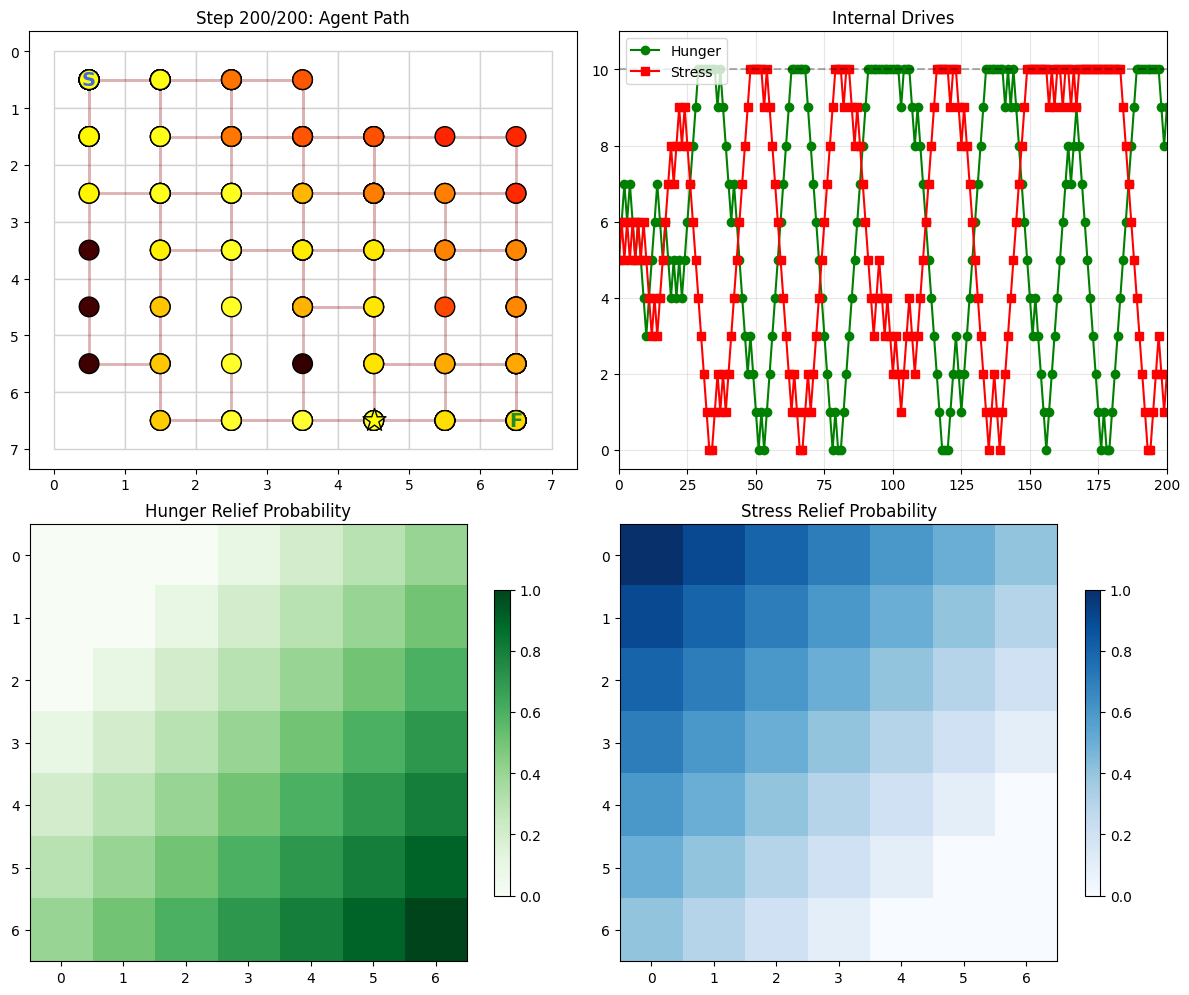

In [66]:
# Loop
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm

# Timesteps
T2 = 200

history_of_locs2 = [start_loc]
history_of_hunger2 = [start_hunger]
history_of_stress2 = [start_stress]
obs2 = env.reset() 
obs2 = [loc_list.index(obs2[0]), hunger_obs_names.index(obs2[1]), stress_obs_names.index(obs2[2])]

# Pre-calculate Heatmaps for visualization efficiency
hunger_grid = np.zeros(grid_dims)
stress_grid = np.zeros(grid_dims)
for y in range(grid_dims[0]):
    for x in range(grid_dims[1]):
         d_f = abs(y - food_location[0]) + abs(x - food_location[1])
         hunger_grid[y, x] = max(0.0, 1.0 - (d_f * reward_likelihood_scale))
         d_s = abs(y - shelter_location[0]) + abs(x - shelter_location[1])
         stress_grid[y, x] = max(0.0, 1.0 - (d_s * reward_likelihood_scale))

print("\nStarting Experiment 2 Simulation...")

for t in range(T2):
    # --- Agent Step ---
    qs = agent.infer_states(obs2)
    agent.infer_policies()
    action_idx = int(agent.sample_action()[0])
    action = actions[action_idx]

    # Only enable if B learning is turned on in the Agent constructor otherwise the history won't be available and B param info gain won't be calculated
    # if t > 0:  
    #     my_agent2.update_B(qs_prev=my_agent2.qs_hist[-2])
    
    loc_obs, hunger_obs, stress_obs = env.step(action)
    
    obs2 = [loc_list.index(loc_obs), hunger_obs_names.index(hunger_obs), stress_obs_names.index(stress_obs)]
    
    history_of_locs2.append(loc_obs)
    history_of_hunger2.append(env.current_hunger)
    history_of_stress2.append(env.current_stress)

    # --- Live Visualization ---
    clear_output(wait=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 1. Agent Path (Top Left)
    ax_path = axes[0, 0]
    ax_path.set_title(f"Step {t+1}/{T2}: Agent Path")
    ax_path.invert_yaxis()
    
    # Grid Background
    for y in range(grid_dims[0]):
        for x in range(grid_dims[1]):
            rect = patches.Rectangle((x, y), 1.0, 1.0, linewidth=1, edgecolor='lightgray', facecolor='white')
            ax_path.add_patch(rect)
    
    # Trajectory & Current Position
    hist_locs = np.vstack(history_of_locs2).astype(float)
    temporal_colormap = cm.hot(np.linspace(0, 0.8, len(hist_locs)))
    
    # Path line
    if len(hist_locs) > 1:
        ax_path.plot(hist_locs[:,1]+0.5, hist_locs[:,0]+0.5, 'darkred', linewidth=2, zorder=2, alpha=0.3)
    
    # Points
    ax_path.scatter(hist_locs[:,1]+0.5, hist_locs[:,0]+0.5, 200, c=temporal_colormap, zorder=3, edgecolors='black')
    
    # Current Head
    current_head = hist_locs[-1]
    ax_path.scatter(current_head[1]+0.5, current_head[0]+0.5, 300, c='yellow', marker='*', zorder=4, edgecolors='black', label='Current')

    # Markers
    ax_path.text(food_location[1]+0.5, food_location[0]+0.5, 'F', ha='center', va='center', fontweight='bold', color='forestgreen', fontsize=14)
    ax_path.text(shelter_location[1]+0.5, shelter_location[0]+0.5, 'S', ha='center', va='center', fontweight='bold', color='royalblue', fontsize=14)

    # 2. Stats (Top Right)
    ax_stats = axes[0, 1]
    ax_stats.set_title("Internal Drives")
    ax_stats.plot(history_of_hunger2, 'g-o', label='Hunger')
    ax_stats.plot(history_of_stress2, 'r-s', label='Stress')
    ax_stats.axhline(y=max_drive, color='k', linestyle='--', alpha=0.3)
    ax_stats.set_xlim(0, T2)
    ax_stats.set_ylim(-0.5, max(max_drive, max_drive)+1)
    ax_stats.legend(loc='upper left')
    ax_stats.grid(True, alpha=0.3)

    # 3. Hunger Map (Bottom Left)
    ax_map1 = axes[1, 0]
    ax_map1.set_title("Hunger Relief Probability")
    im1 = ax_map1.imshow(hunger_grid, cmap='Greens', vmin=0, vmax=1.0)
    fig.colorbar(im1, ax=ax_map1, shrink=0.7)
    
    # 4. Stress Map (Bottom Right)
    ax_map2 = axes[1, 1]
    ax_map2.set_title("Stress Relief Probability")
    im2 = ax_map2.imshow(stress_grid, cmap='Blues', vmin=0, vmax=1.0)
    fig.colorbar(im2, ax=ax_map2, shrink=0.7)
    
    plt.tight_layout()
    plt.show()